<a href="https://colab.research.google.com/github/dmmcatee/week3-dimensionality-reduction/blob/main/M4_Data_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 Introduction & Setup

In this assignment, I will practice data exploration, feature engineering, and basic modeling using Python and scikit-learn. I will also document my workflow using GitHub.


##2 Data Loading & Exploration
In this section, the Adult Census Income dataset is loaded and explored to understand the structure and characteristics of the data before performing feature engineering.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url = "https://huggingface.co/datasets/scikit-learn/adult-census-income/resolve/main/adult.csv"
df = pd.read_csv(url)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 3 Summary Statistics Explanation

The dataset contains 32,561 individuals with an average age of approximately 39 years. Most individuals work around 40 hours per week. Capital gain and loss values are zero for most individuals, indicating highly skewed distributions. Education levels cluster around high school and some college levels.

In [77]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 4 Missing Values Explanation

Missing values in the dataset were initially encoded as "?". These values were converted to NaN so they could be properly identified and handled during analysis. After conversion, missing values were identified in columns such as workclass, occupation, and native country.

In [78]:
df.replace("?", np.nan, inplace=True)

In [79]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
sex,0


## 5 Feature Type Identification

Numerical features include age, final weight, education number, capital gains, capital losses, and hours worked per week. Categorical features include work class, education, occupation, marital status, and income category.

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [81]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_features)
print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

Categorical Features:
Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'sex', 'native.country', 'income'],
      dtype='object')


## 6 Histogram Explanation

The histogrram shows that individuals fall between ages 25 and 50, with fewer individuals at very young and older ages.

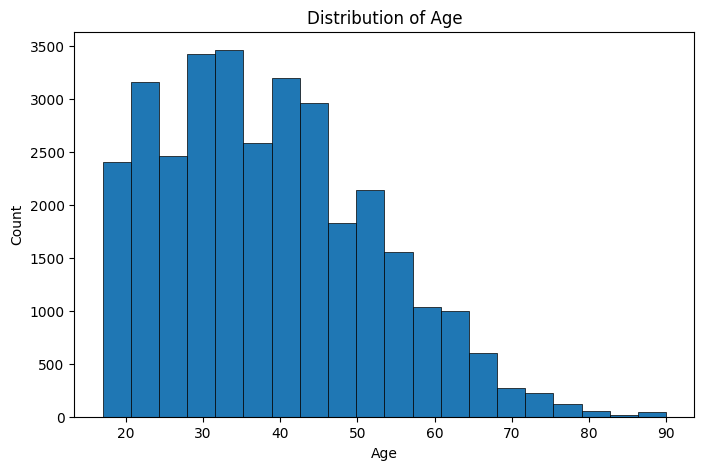

In [82]:
plt.figure(figsize=(8,5))
plt.hist(df['age'], bins=20, edgecolor='black', linewidth=0.5)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Distribution of Age")
plt.show()

## 7 Scatter Plot Explanation

The scatter plot shows that most individuals work around 40 hours per week regardless of age, although somes variation exists among different age groups.

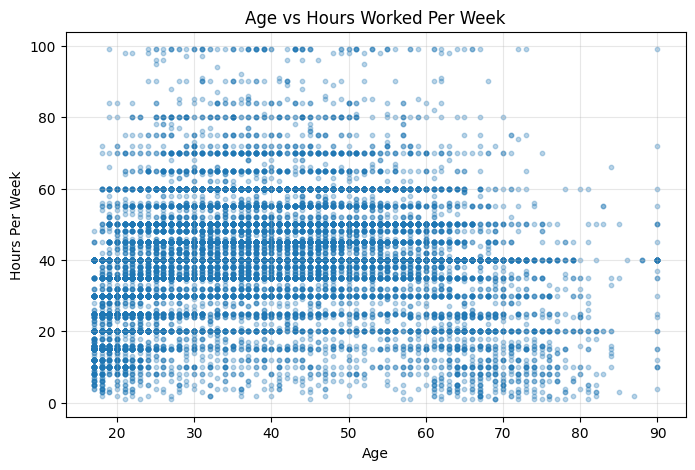

In [83]:
plt.figure(figsize=(8,5))
plt.scatter(df['age'], df['hours.per.week'], alpha=0.3, s=10)
plt.xlabel("Age")
plt.ylabel("Hours Per Week")
plt.title("Age vs Hours Worked Per Week")
plt.grid(alpha=0.3)
plt.show()

## 8 Encoding Explanation

One-hot encoding was applied to categorical variables to convert them into numerical format so they can be used in machine learning models.

In [84]:
categorical_features = df.select_dtypes(include=['object']).columns
categorical_features = categorical_features.drop('income')
df_encoded = pd.get_dummies(df, columns=categorical_features)
df_encoded.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,<=50K,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## 9 Feature Engineering Explanation

A new feature called *age_group* was created by grouping ages into categories representing life stages. This helps models capture patterns related to age more effectively.

In [85]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 45, 65, 100],
    labels=['Young', 'Adult', 'Middle-Aged', 'Senior']
)
df[['age', 'age_group']].head()

,age,age_group
0,90,Senior
1,82,Senior
2,66,Senior
3,54,Middle-Aged
4,41,Adult


In [86]:
df_encoded['income'] = df_encoded['income'].astype(str).str.strip()

In [87]:
df_encoded['income_binary'] = (
    df_encoded['income'].str.strip() == '>50K'
).astype(int)

In [88]:
X = df_encoded.drop(['income', 'income_binary'], axis=1)
y = df_encoded['income_binary']

In [89]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

In [91]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [92]:
y_pred = model.predict(X_test)

In [93]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.11693339995528237
R^2 Score: 0.35144547380481417


## Basic Modeling Explanation

The trained model achieved an MSE of approximately 0.117 and an R^2 score of 0.35. This indicates that the model explains around 35% of the variation in income category. While not perfect, the model demonstrates moderate predictive capability given the simplicity of linear regression and the complexity of income prediction.

## Reflection

### Challenges and Surprises in Feature Engineering
One challenge during feature engineering was handling categorical variables and ensuring missing or incorrectly formatted values were properly processed. Another challenge was avoiding data leakage when encoding variables, especially ensuring that income-related information was not accidentally included in the feature set. It was surprising how small preprocessing issues, such as whitespace in category labels or class imbalance, could significantly affect model behavior.

### Impact of Feature Engineering Choices on Model Performance
Encoding categorical variables using one-hot encoding allowed the model to use information from non-numerical data, improving predictive capability. Creating derived features such as grouped age categories also helped capture patterns that raw numerical values alone might not fully represent. However, using linear regression for a classification-style problem limited performance, showing that model choice also plays an important role.

### Improvements for Future Work
In future analyses, I would improve my workflow by performing more careful data cleaning earlier in the process adn using stratified sampling consistently when splitting data. I would also explore classification models such as logistic regression or decision trees, and apply feature scaling or additional feature engineering techniques to improve performance. Finally, organizing notebook steps more carefully from the beginning would reduce debugging time.